# Linear Regression with Gradience
This notebook demonstrates how to build and train a simple Linear Regression model using the Gradience deep learning framework from scratch.

In [6]:
import sys
import os
sys.path.append(os.path.abspath('..')) # Ensure gradience is in path

import numpy as np
import matplotlib.pyplot as plt

from gradience.tensor import Tensor
from gradience.nn.layers.linear import Linear
from gradience.nn.losses.mse import MSELoss
from gradience.optim.sgd import SGD

## 1. Generate Synthetic Data
We will generate data for the equation $y = 2x + 1$ with some added Gaussian noise.

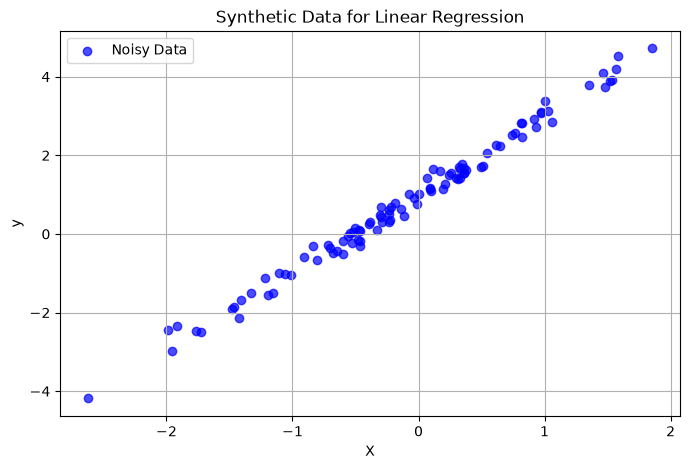

In [7]:
np.random.seed(42)
X_data = np.random.randn(100, 1)
y_data = 2.0 * X_data + 1.0 + (np.random.randn(100, 1) * 0.2)

plt.figure(figsize=(8, 5))
plt.scatter(X_data, y_data, alpha=0.7, color='blue', label='Noisy Data')
plt.title('Synthetic Data for Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

X = Tensor(X_data)
y = Tensor(y_data)

## 2. Define the Model, Loss, and Optimizer
We will use a single `Linear(1, 1)` layer, `MSELoss`, and `SGD` optimizer.

In [8]:
model = Linear(in_features=1, out_features=1)
criterion = MSELoss()
optimizer = SGD(model.parameters(), lr=0.1)

## 3. Training Loop
We will train the model for 100 epochs, tracking the loss over time.

In [9]:
epochs = 100
losses = []

for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = model(X)
    loss = criterion(predictions, y)
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:03d}/{epochs} | Loss: {loss.item():.4f}')

Epoch 010/100 | Loss: 0.1501
Epoch 020/100 | Loss: 0.0392
Epoch 030/100 | Loss: 0.0355
Epoch 040/100 | Loss: 0.0353
Epoch 050/100 | Loss: 0.0353
Epoch 060/100 | Loss: 0.0353
Epoch 070/100 | Loss: 0.0353
Epoch 080/100 | Loss: 0.0353
Epoch 090/100 | Loss: 0.0353
Epoch 100/100 | Loss: 0.0353


## 4. Analysis and Visualization
Let's plot the loss curve and the final learned regression line.

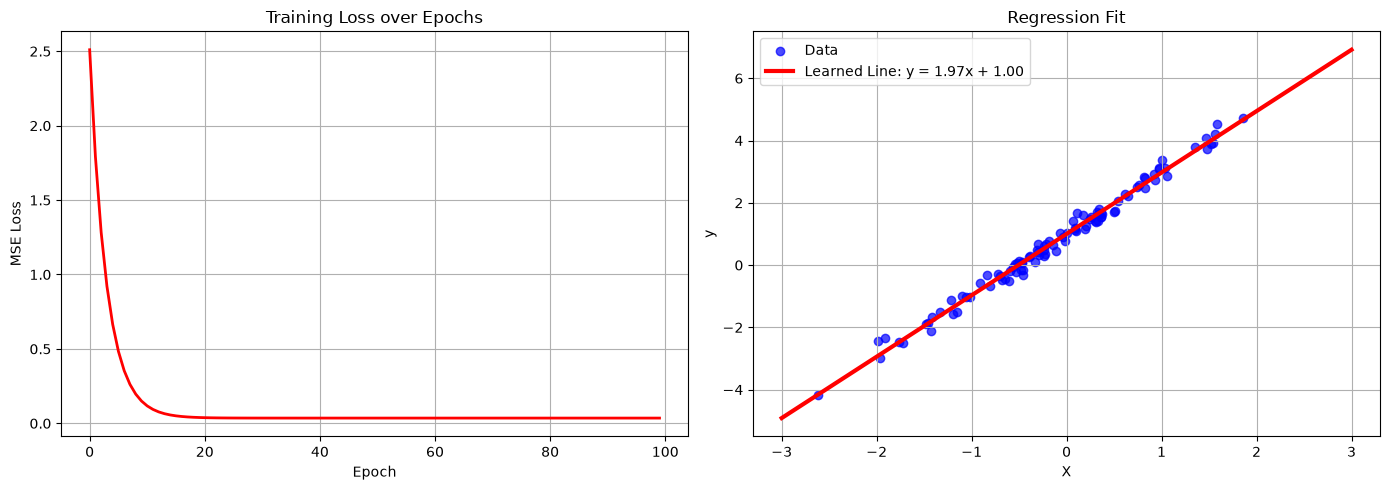

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curve
ax1.plot(losses, color='red', linewidth=2)
ax1.set_title('Training Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.grid(True)

# Learned Line vs Data
learned_weight = model.weight.data[0][0]
learned_bias = model.bias.data[0]
line_x = np.linspace(-3, 3, 100)
line_y = learned_weight * line_x + learned_bias

ax2.scatter(X_data, y_data, alpha=0.7, color='blue', label='Data')
ax2.plot(line_x, line_y, color='red', linewidth=3, label=f'Learned Line: y = {learned_weight:.2f}x + {learned_bias:.2f}')
ax2.set_title('Regression Fit')
ax2.set_xlabel('X')
ax2.set_ylabel('y')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 5. PyTorch Comparison
To prove the mathematical correctness of the Gradience autograd engine, we will replicate the exact same model and training loop using PyTorch, and compare the loss curves.

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

# Convert data to PyTorch tensors
X_pt = torch.tensor(X_data, dtype=torch.float32)
y_pt = torch.tensor(y_data, dtype=torch.float32)

# Define identical PyTorch model
pt_model = nn.Linear(1, 1)
# To ensure a completely fair comparison, we could copy weights, but random init is fine too
pt_criterion = nn.MSELoss()
pt_optimizer = optim.SGD(pt_model.parameters(), lr=0.1)

pt_losses = []

for epoch in range(epochs):
    pt_optimizer.zero_grad()
    pt_preds = pt_model(X_pt)
    loss = pt_criterion(pt_preds, y_pt)
    loss.backward()
    pt_optimizer.step()
    
    pt_losses.append(loss.item())

### Plot Gradience vs PyTorch

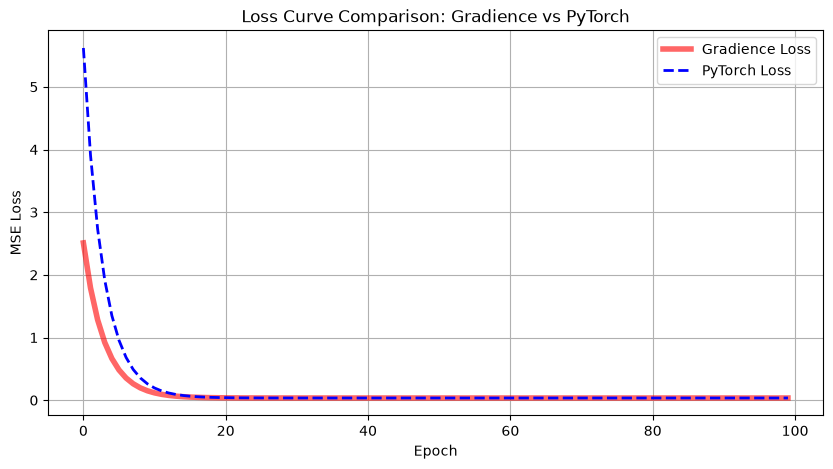

Gradience Final Loss: 0.03534529929165818
PyTorch Final Loss:   0.03534529730677605


In [12]:
plt.figure(figsize=(10, 5))
plt.plot(losses, color='red', linewidth=4, alpha=0.6, label='Gradience Loss')
plt.plot(pt_losses, color='blue', linewidth=2, linestyle='--', label='PyTorch Loss')
plt.title('Loss Curve Comparison: Gradience vs PyTorch')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

print('Gradience Final Loss:', losses[-1])
print('PyTorch Final Loss:  ', pt_losses[-1])